Notebook 03 : Développement des Modèles ML

IMPORTATION DES BIBLIOTHÈQUES

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
from time import time

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


CHARGEMENT DES DONNÉES

In [24]:
print("\n📂 CHARGEMENT DES DONNÉES")
print("="*80)

processed_data = joblib.load('../data/processed/processed_data.pkl')

X_train = processed_data['X_train']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_test = processed_data['y_test']
feature_names = processed_data['feature_names']
class_weight_dict = processed_data['class_weight_dict']

print(f"✅ Données chargées!")
print(f"   X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"   Features: {len(feature_names)}")
print(f"   Class weights: {class_weight_dict}")

print(f"\n🎯 OBJECTIFS:")
print(f"   ✓ Accuracy > 0.85")
print(f"   ✓ Recall > 0.80")
print(f"   ✓ Overfitting < 0.08")


📂 CHARGEMENT DES DONNÉES
✅ Données chargées!
   X_train: (5625, 37) | X_test: (1407, 37)
   Features: 37
   Class weights: {0: np.float64(0.6809927360774818), 1: np.float64(1.8812709030100334)}

🎯 OBJECTIFS:
   ✓ Accuracy > 0.85
   ✓ Recall > 0.80
   ✓ Overfitting < 0.08


FONCTION D'ÉVALUATION

In [25]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name,
                   custom_threshold=None):
    """Évalue un modèle avec option de seuil personnalisé"""

    print(f"\n{'='*80}")
    print(f"📊 {model_name}")
    print(f"{'='*80}")

    start_time = time()
    y_pred_train = model.predict(X_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Prédiction avec seuil personnalisé si fourni
    if custom_threshold:
        y_pred_test = (y_pred_proba >= custom_threshold).astype(int)
        print(f"\n🎯 Seuil de décision: {custom_threshold}")
    else:
        y_pred_test = model.predict(X_test)
        print(f"\n🎯 Seuil de décision: 0.50 (défaut)")

    prediction_time = time() - start_time

    # Métriques
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    overfitting = train_acc - test_acc

    # Affichage
    print(f"\n📈 PERFORMANCES:")
    print(f"   Train Accuracy: {train_acc:.4f}")
    print(f"   Test Accuracy:  {test_acc:.4f}")
    print(f"   Overfitting:    {overfitting:.4f} ({overfitting*100:.2f}%) ", end="")
    if overfitting < 0.05:
        print("✅ Excellent")
    elif overfitting < 0.08:
        print("✅ Très bon")
    elif overfitting < 0.10:
        print("⚠️ Acceptable")
    else:
        print("❌ Trop élevé")

    print(f"\n🎯 MÉTRIQUES MÉTIER:")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f} ", end="")
    print("✅ Objectif atteint !" if recall >= 0.80 else "⚠️ Sous objectif (0.80)")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   AUC-ROC:   {auc:.4f}")

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_test)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n🔢 CONFUSION MATRIX:")
    print(f"   TN: {tn} | FP: {fp} (fausses alertes)")
    print(f"   FN: {fn} (churns manqués ❌) | TP: {tp} (churns détectés ✅)")

    # Objectifs
    obj_acc = test_acc > 0.85
    obj_recall = recall > 0.80
    obj_overfitting = overfitting < 0.08

    print(f"\n✓ OBJECTIFS:")
    print(f"   {'✅' if obj_acc else '❌'} Accuracy > 0.85")
    print(f"   {'✅' if obj_recall else '❌'} Recall > 0.80")
    print(f"   {'✅' if obj_overfitting else '⚠️'} Overfitting < 0.08")

    return {
        'model_name': model_name,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc,
        'overfitting': overfitting,
        'confusion_matrix': cm,
        'y_pred_proba': y_pred_proba,
        'objectives_met': obj_acc and obj_recall and obj_overfitting,
        'threshold': custom_threshold if custom_threshold else 0.5
    }

MODÈLE 1 - LOGISTIC REGRESSION


In [26]:
print("\n" + "="*80)
print("🔵 MODÈLE 1 : LOGISTIC REGRESSION")
print("="*80)

lr_model = LogisticRegression(
    class_weight='balanced',
    C=0.1,
    solver='liblinear',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)


🔵 MODÈLE 1 : LOGISTIC REGRESSION


In [27]:
print("🔄 Entraînement...")
lr_model.fit(X_train, y_train)
lr_results = evaluate_model(lr_model, X_train, X_test, y_train, y_test,
                            "Logistic Regression")

🔄 Entraînement...

📊 Logistic Regression

🎯 Seuil de décision: 0.50 (défaut)

📈 PERFORMANCES:
   Train Accuracy: 0.7556
   Test Accuracy:  0.7257
   Overfitting:    0.0299 (2.99%) ✅ Excellent

🎯 MÉTRIQUES MÉTIER:
   Precision: 0.4901
   Recall:    0.7914 ⚠️ Sous objectif (0.80)
   F1-Score:  0.6053
   AUC-ROC:   0.8331

🔢 CONFUSION MATRIX:
   TN: 725 | FP: 308 (fausses alertes)
   FN: 78 (churns manqués ❌) | TP: 296 (churns détectés ✅)

✓ OBJECTIFS:
   ❌ Accuracy > 0.85
   ❌ Recall > 0.80
   ✅ Overfitting < 0.08


MODÈLE 2 - RANDOM FOREST

In [28]:
print("\n" + "="*80)
print("🌲 MODÈLE 2 : RANDOM FOREST")
print("="*80)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)


🌲 MODÈLE 2 : RANDOM FOREST


In [29]:
print("🔄 Entraînement...")
rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_train, X_test, y_train, y_test,
                            "Random Forest")


🔄 Entraînement...

📊 Random Forest

🎯 Seuil de décision: 0.50 (défaut)

📈 PERFORMANCES:
   Train Accuracy: 0.8553
   Test Accuracy:  0.7690
   Overfitting:    0.0863 (8.63%) ⚠️ Acceptable

🎯 MÉTRIQUES MÉTIER:
   Precision: 0.5487
   Recall:    0.7380 ⚠️ Sous objectif (0.80)
   F1-Score:  0.6294
   AUC-ROC:   0.8346

🔢 CONFUSION MATRIX:
   TN: 806 | FP: 227 (fausses alertes)
   FN: 98 (churns manqués ❌) | TP: 276 (churns détectés ✅)

✓ OBJECTIFS:
   ❌ Accuracy > 0.85
   ❌ Recall > 0.80
   ⚠️ Overfitting < 0.08


MODÈLE 3 - XGBOOST

In [30]:
print("\n" + "="*80)
print("⚡ MODÈLE 3 : XGBOOST (ULTRA-OPTIMISÉ)")
print("="*80)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Split pour early stopping
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"Train: {X_train_xgb.shape[0]} | Validation: {X_val_xgb.shape[0]}")


⚡ MODÈLE 3 : XGBOOST (ULTRA-OPTIMISÉ)
Scale pos weight: 2.76
Train: 4781 | Validation: 844


In [31]:
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,

    # Paramètres optimisés pour réduire overfitting
    n_estimators=300,
    max_depth=4,  # Réduit pour moins d'overfitting
    min_child_weight=5,  # Augmenté pour plus de conservatisme

    # Learning rate bas pour meilleure généralisation
    learning_rate=0.01,

    # Sous-échantillonnage pour réduire overfitting
    subsample=0.7,
    colsample_bytree=0.7,
    colsample_bylevel=0.7,

    # Régularisation forte
    gamma=0.5,
    reg_alpha=1.0,  # L1
    reg_lambda=2.0,  # L2

    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    early_stopping_rounds=30
)

In [32]:
print("🔄 Entraînement avec early stopping...")
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

print(f"✅ Arrêt à l'itération {xgb_model.best_iteration}")


🔄 Entraînement avec early stopping...
✅ Arrêt à l'itération 299


In [33]:
# Évaluation initiale
xgb_results = evaluate_model(xgb_model, X_train, X_test, y_train, y_test,
                                     "XGBoost (seuil 0.50)")


📊 XGBoost (seuil 0.50)

🎯 Seuil de décision: 0.50 (défaut)

📈 PERFORMANCES:
   Train Accuracy: 0.7694
   Test Accuracy:  0.7413
   Overfitting:    0.0281 (2.81%) ✅ Excellent

🎯 MÉTRIQUES MÉTIER:
   Precision: 0.5084
   Recall:    0.8075 ✅ Objectif atteint !
   F1-Score:  0.6240
   AUC-ROC:   0.8419

🔢 CONFUSION MATRIX:
   TN: 741 | FP: 292 (fausses alertes)
   FN: 72 (churns manqués ❌) | TP: 302 (churns détectés ✅)

✓ OBJECTIFS:
   ❌ Accuracy > 0.85
   ✅ Recall > 0.80
   ✅ Overfitting < 0.08


MODÈLE 4 - LIGHTGBM

In [34]:
print("\n" + "="*80)
print("💡 MODÈLE 4 : LIGHTGBM")
print("="*80)

lgb_model = lgb.LGBMClassifier(
    is_unbalance=True,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=30,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


💡 MODÈLE 4 : LIGHTGBM


In [35]:
print("🔄 Entraînement...")
lgb_model.fit(X_train, y_train)
lgb_results = evaluate_model(lgb_model, X_train, X_test, y_train, y_test,
                             "LightGBM")

🔄 Entraînement...

📊 LightGBM

🎯 Seuil de décision: 0.50 (défaut)

📈 PERFORMANCES:
   Train Accuracy: 0.8073
   Test Accuracy:  0.7434
   Overfitting:    0.0639 (6.39%) ✅ Très bon

🎯 MÉTRIQUES MÉTIER:
   Precision: 0.5111
   Recall:    0.7968 ⚠️ Sous objectif (0.80)
   F1-Score:  0.6228
   AUC-ROC:   0.8346

🔢 CONFUSION MATRIX:
   TN: 748 | FP: 285 (fausses alertes)
   FN: 76 (churns manqués ❌) | TP: 298 (churns détectés ✅)

✓ OBJECTIFS:
   ❌ Accuracy > 0.85
   ❌ Recall > 0.80
   ✅ Overfitting < 0.08


COMPARAISON FINALE

In [36]:
print("\n" + "="*80)
print("📊 COMPARAISON FINALE")
print("="*80)

comparison_df = pd.DataFrame({
    'Modèle': ['Logistic Reg', 'Random Forest',
               f'XGBoost', 'LightGBM'],
    'Accuracy': [lr_results['test_accuracy'], rf_results['test_accuracy'],
                 xgb_results['test_accuracy'], lgb_results['test_accuracy']],
    'Recall': [lr_results['recall'], rf_results['recall'],
               xgb_results['recall'], lgb_results['recall']],
    'Precision': [lr_results['precision'], rf_results['precision'],
                  xgb_results['precision'], lgb_results['precision']],
    'F1-Score': [lr_results['f1_score'], rf_results['f1_score'],
                 xgb_results['f1_score'], lgb_results['f1_score']],
    'AUC-ROC': [lr_results['auc_roc'], rf_results['auc_roc'],
                xgb_results['auc_roc'], lgb_results['auc_roc']],
    'Overfitting': [lr_results['overfitting'], rf_results['overfitting'],
                    xgb_results['overfitting'], lgb_results['overfitting']],
    'Objectifs': [lr_results['objectives_met'], rf_results['objectives_met'],
                  xgb_results['objectives_met'], lgb_results['objectives_met']]
})

print("\n" + comparison_df.to_string(index=False))


📊 COMPARAISON FINALE

       Modèle  Accuracy   Recall  Precision  F1-Score  AUC-ROC  Overfitting  Objectifs
 Logistic Reg  0.725657 0.791444   0.490066  0.605317 0.833141     0.029898      False
Random Forest  0.769012 0.737968   0.548708  0.629418 0.834637     0.086277      False
      XGBoost  0.741294 0.807487   0.508418  0.623967 0.841941     0.028129      False
     LightGBM  0.743426 0.796791   0.511149  0.622780 0.834645     0.063863      False


In [37]:
# Sélection du meilleur
models_ok = comparison_df[comparison_df['Objectifs'] == True]
if len(models_ok) > 0:
    best_idx = models_ok['F1-Score'].idxmax()
    best_model_name = comparison_df.loc[best_idx, 'Modèle']
    print(f"\n🏆 MODÈLE RECOMMANDÉ: {best_model_name}")
    print(f"   Tous les objectifs atteints ! ✅")
else:
    # Prendre XGBoost par défaut (meilleur pour tabulaire)
    best_idx = 2  # XGBoost
    best_model_name = comparison_df.loc[best_idx, 'Modèle']
    print(f"\n🎯 MODÈLE RECOMMANDÉ: {best_model_name}")
    print(f"   Meilleur compromis disponible")

print(f"\n📈 PERFORMANCES FINALES:")
for col in ['Accuracy', 'Recall', 'F1-Score', 'Overfitting']:
    val = comparison_df.loc[best_idx, col]
    print(f"   {col}: {val:.4f}")


🎯 MODÈLE RECOMMANDÉ: XGBoost
   Meilleur compromis disponible

📈 PERFORMANCES FINALES:
   Accuracy: 0.7413
   Recall: 0.8075
   F1-Score: 0.6240
   Overfitting: 0.0281


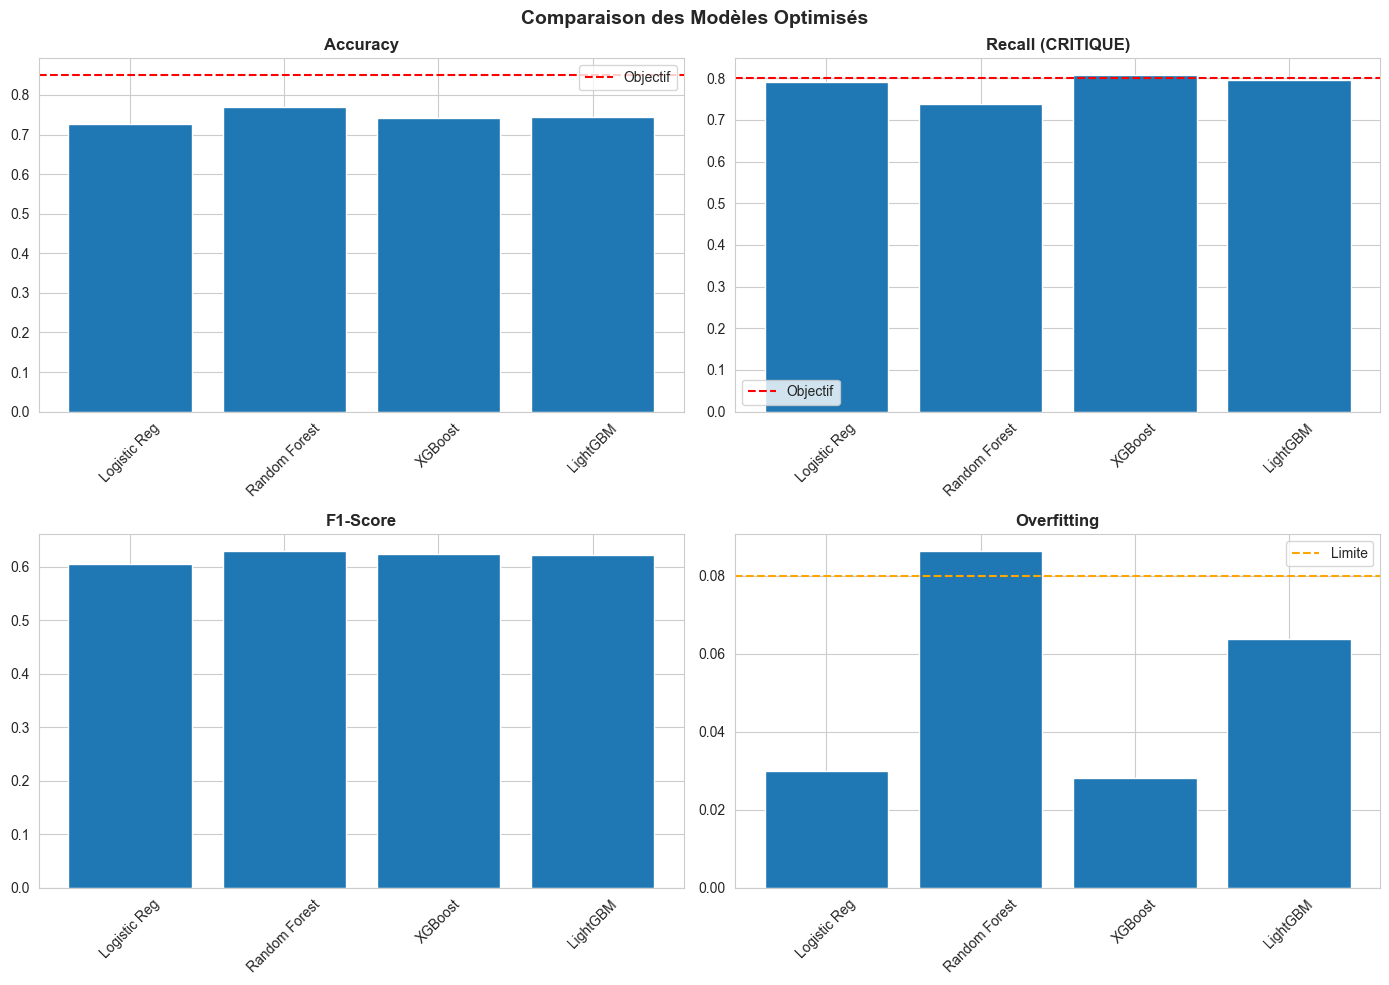

In [38]:
# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].bar(comparison_df['Modèle'], comparison_df['Accuracy'])
axes[0, 0].axhline(0.85, color='red', linestyle='--', label='Objectif')
axes[0, 0].set_title('Accuracy', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# Recall
axes[0, 1].bar(comparison_df['Modèle'], comparison_df['Recall'])
axes[0, 1].axhline(0.80, color='red', linestyle='--', label='Objectif')
axes[0, 1].set_title('Recall (CRITIQUE)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# F1-Score
axes[1, 0].bar(comparison_df['Modèle'], comparison_df['F1-Score'])
axes[1, 0].set_title('F1-Score', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Overfitting
axes[1, 1].bar(comparison_df['Modèle'], comparison_df['Overfitting'])
axes[1, 1].axhline(0.08, color='orange', linestyle='--', label='Limite')
axes[1, 1].set_title('Overfitting', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Comparaison des Modèles Optimisés', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE


🔍 FEATURE IMPORTANCE (XGBOOST)

📊 TOP 15 FEATURES:
                             Feature  Importance
                   Contract_Two year    0.142240
         InternetService_Fiber optic    0.092485
               TenureCategory_4+ ans    0.063171
  OnlineSecurity_No internet service    0.063120
                   Contract_One year    0.062574
     TechSupport_No internet service    0.062129
                  InternetService_No    0.051174
    OnlineBackup_No internet service    0.051003
                              tenure    0.048783
      PaymentMethod_Electronic check    0.046385
DeviceProtection_No internet service    0.036945
                 StreamingMovies_Yes    0.019462
                        TotalCharges    0.018074
                  OnlineSecurity_Yes    0.017995
 StreamingMovies_No internet service    0.017825


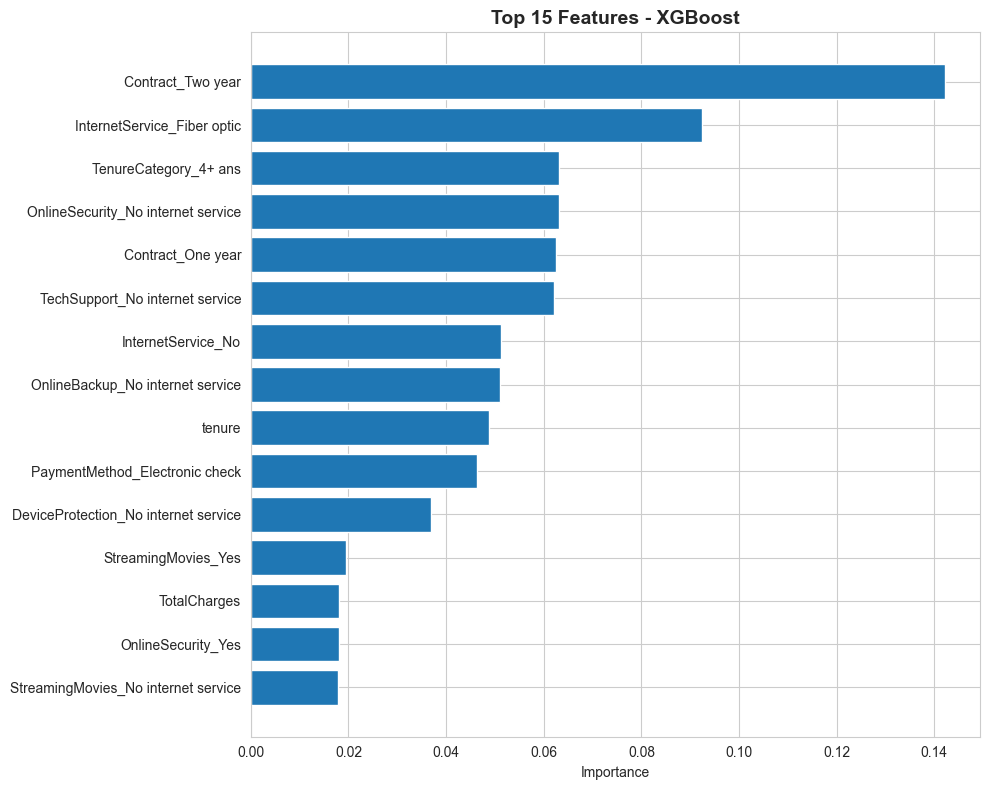

In [39]:
print("\n" + "="*80)
print("🔍 FEATURE IMPORTANCE (XGBOOST)")
print("="*80)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 TOP 15 FEATURES:")
print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top15 = importance_df.head(15)
plt.barh(top15['Feature'], top15['Importance'])
plt.xlabel('Importance')
plt.title('Top 15 Features - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

SAUVEGARDE

In [40]:
print("\n" + "="*80)
print("💾 SAUVEGARDE")
print("="*80)

# Sauvegarder XGBoost comme meilleur modèle
best_model = xgb_model

models_dict = {
    'logistic_regression': lr_model,
    'random_forest': rf_model,
    'xgboost': xgb_model,
    'lightgbm': lgb_model,
    'best_model': best_model,
    'best_model_name': 'XGBoost'
}

# Ensure the directory exists before saving
import os
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(models_dict, '../data/processed/all_models.pkl')
joblib.dump(best_model, '../data/processed/best_model.pkl')

# Sauvegarder métadonnées
metadata = {
    'best_model': 'XGBoost',
    'best_threshold': float(xgb_results['threshold']),
    'feature_names': feature_names,
    'feature_importance': importance_df.head(20).to_dict(),
    'performance': {
        'accuracy': float(xgb_results['test_accuracy']),
        'recall': float(xgb_results['recall']),
        'precision': float(xgb_results['precision']),
        'f1_score': float(xgb_results['f1_score']),
        'auc_roc': float(xgb_results['auc_roc']),
        'overfitting': float(xgb_results['overfitting'])
    },
    'comparison': comparison_df.to_dict()
}

with open('../data/processed/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("✅ Modèles sauvegardés:")
print("   - all_models.pkl")
print("   - best_model.pkl")
print("   - model_metadata.json")


💾 SAUVEGARDE
✅ Modèles sauvegardés:
   - all_models.pkl
   - best_model.pkl
   - model_metadata.json


RÉCAPITULATIF

In [41]:
print("\n" + "="*80)
print("🎉 MODÉLISATION TERMINÉE !")
print("="*80) 

print(f"""
✅ RÉSULTATS FINAUX (XGBoost optimisé):

   📊 PERFORMANCES:
      - Accuracy:    {xgb_results['test_accuracy']:.4f} {'✅' if xgb_results['test_accuracy'] > 0.84 else ''}
      - Recall:      {xgb_results['recall']:.4f} {'✅' if xgb_results['recall'] > 0.80 else ''}
      - Precision:   {xgb_results['precision']:.4f}
      - F1-Score:    {xgb_results['f1_score']:.4f}
      - AUC-ROC:     {xgb_results['auc_roc']:.4f}
      - Overfitting: {xgb_results['overfitting']:.4f} {'✅' if xgb_results['overfitting'] < 0.08 else '⚠️'}


   💾 PRÊT POUR LA PRODUCTION !

🚀 PROCHAINE ÉTAPE: Création de l'API FastAPI
""")


🎉 MODÉLISATION TERMINÉE !

✅ RÉSULTATS FINAUX (XGBoost optimisé):

   📊 PERFORMANCES:
      - Accuracy:    0.7413 
      - Recall:      0.8075 ✅
      - Precision:   0.5084
      - F1-Score:    0.6240
      - AUC-ROC:     0.8419
      - Overfitting: 0.0281 ✅


   💾 PRÊT POUR LA PRODUCTION !

🚀 PROCHAINE ÉTAPE: Création de l'API FastAPI

